# TGCN on daily asset correlation

Each asset is a node. The node vector on day $t$ is the 63-session z-score of that asset's features. Edge weights are that day's cosine similarity from `StockVectorMachine._get_asset_correlation`, shifted to $[0, 1]$. The target is the next day's cosine matrix.

Train through 2022, test from 2023 onward.

In [47]:
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable):
        return iterable

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric_temporal.nn.recurrent import TGCN
from torch_geometric_temporal.signal import DynamicGraphTemporalSignal

from stock_vector_machine import StockVectorMachine

## Standardized feature cube

`StockVectorMachine` z-scores every numeric column over a trailing 63-session window. Stack those panels in the same asset order the class uses for cosine.

In [48]:
raw = pd.read_csv("./data/rl_features.csv", parse_dates=["date"])
stc = StockVectorMachine(raw.copy())
stc._preprocess_data()

feature_cols = [c for c in stc._features if c not in ("date", "tic")]
assets = list(stc.assets)
dates = pd.DatetimeIndex(pd.to_datetime(stc.standardized[assets[0]]["date"]))

X = np.stack([
    stc.standardized[a].set_index("date")[feature_cols].to_numpy(dtype=np.float64)
    for a in assets
])
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
n_assets, n_dates, n_features = X.shape

print(f"dates: {dates.min().date()} to {dates.max().date()}")
print(f"n_assets={n_assets}, n_dates={n_dates}, n_features={n_features}")

dates: 2016-05-06 to 2026-01-16
n_assets=100, n_dates=2439, n_features=19


## Daily cosine graph

`_get_asset_correlation` is the `(assets, assets, dates)` cosine tensor. Shift it to $[0, 1]$ for TGCN's GCN layer. The graph is complete and directed, with self-loops omitted (`i != j`).

In [49]:
cosine = np.nan_to_num(stc._get_asset_correlation(), nan=0.0, posinf=0.0, neginf=0.0)
assert cosine.shape == (n_assets, n_assets, n_dates)
weights = np.clip((cosine + 1.0) / 2.0, 0.0, 1.0)

src, dst = np.where(~np.eye(n_assets, dtype=bool))
edge_index = np.stack([src, dst], axis=0).astype(np.int64)

print(f"edge_index {edge_index.shape}, cosine {cosine.shape}")

edge_index (2, 9900), cosine (100, 100, 2439)


## Train / test snapshots

Split on the feature date: snapshots on or before 2022-12-31 train, 2023-01-01 onward test. Each snapshot uses today's node features and cosine graph; `y` is tomorrow's cosine matrix. The last calendar day is dropped because it has no next cosine.

In [50]:
TRAIN_END = pd.Timestamp("2022-12-31")
TEST_START = pd.Timestamp("2023-01-01")
snap_dates = dates[:-1]
train_mask = np.asarray(snap_dates <= TRAIN_END)
test_mask = np.asarray(snap_dates >= TEST_START)


def make_signal(mask):
    idx = np.flatnonzero(mask)
    features = [X[:, t, :].astype(np.float32) for t in idx]
    targets = [cosine[:, :, t + 1].astype(np.float32) for t in idx]
    edge_indices = [edge_index] * len(idx)
    edge_weights = [weights[src, dst, t].astype(np.float32) for t in idx]
    return DynamicGraphTemporalSignal(edge_indices, edge_weights, features, targets)


train_dataset = make_signal(train_mask)
test_dataset = make_signal(test_mask)
print(f"train snapshots: {int(train_mask.sum())}")
print(f"test snapshots: {int(test_mask.sum())}")

train snapshots: 1676
test snapshots: 762


## Model

TGCN with 32 hidden units, then a linear head that maps each node's state to a row of the next-day cosine matrix (`n_assets` outputs).

In [51]:
class RecurrentGCN(torch.nn.Module):
    def __init__(self, node_features, n_assets):
        super(RecurrentGCN, self).__init__()
        self.recurrent = TGCN(node_features, 32)
        self.linear = torch.nn.Linear(32, n_assets)

    def forward(self, x, edge_index, edge_weight, prev_hidden_state):
        h = self.recurrent(x, edge_index, edge_weight, prev_hidden_state)
        y = F.relu(h)
        y = self.linear(y)
        return y, h


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RecurrentGCN(node_features=n_features, n_assets=n_assets).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print(device, n_features, n_assets)

cuda 19 100


## Train

Backprop through the whole training history at once would unroll about 1,600 TGCN steps. Each epoch therefore accumulates 63 snapshots (one quarter), then steps the optimizer and detaches the hidden state.

Weights are written to `artifacts/tgcn_next_day_cosine.pt` after training. Re-run that save cell if the model is already in memory.

In [ ]:
CHUNK = 63
n_train = int(train_mask.sum())
model.train()

for epoch in tqdm(range(50)):
    hidden_state = None
    cost = 0
    n_in_chunk = 0
    optimizer.zero_grad()
    for time, snapshot in enumerate(train_dataset):
        x = snapshot.x.to(device)
        edge_index_t = snapshot.edge_index.to(device)
        edge_attr = snapshot.edge_attr.to(device)
        y = snapshot.y.to(device)
        y_hat, hidden_state = model(x, edge_index_t, edge_attr, hidden_state)
        cost = cost + torch.mean((y_hat - y) ** 2)
        n_in_chunk += 1
        last = time == n_train - 1
        if n_in_chunk == CHUNK or last:
            cost = cost / n_in_chunk
            cost.backward()
            optimizer.step()
            optimizer.zero_grad()
            hidden_state = None if hidden_state is None else hidden_state.detach()
            cost = 0
            n_in_chunk = 0

from pathlib import Path

CKPT_PATH = Path("artifacts/tgcn_next_day_cosine.pt")
CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "state_dict": model.state_dict(),
        "n_features": n_features,
        "n_assets": n_assets,
        "hidden_size": 32,
        "chunk": CHUNK,
        "epochs": 50,
        "lr": 0.01,
        "train_end": str(TRAIN_END),
    },
    CKPT_PATH,
)
print(f"saved {CKPT_PATH.resolve()}")

In [53]:
from pathlib import Path

CKPT_PATH = Path("artifacts/tgcn_next_day_cosine.pt")
CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "state_dict": model.state_dict(),
        "n_features": n_features,
        "n_assets": n_assets,
        "hidden_size": 32,
        "chunk": CHUNK,
        "epochs": 50,
        "lr": 0.01,
        "train_end": str(TRAIN_END),
    },
    CKPT_PATH,
)
print(f"saved {CKPT_PATH.resolve()}")

saved /home/ashu/Projects/python/precog_test/artifacts/tgcn_next_day_cosine.pt


## Test

Evaluate from a zero hidden state. Report model MSE and persistence MSE (today's cosine as the forecast of tomorrow's).

In [54]:
model.eval()
cost = 0
hidden_state = None
with torch.no_grad():
    for time, snapshot in enumerate(test_dataset):
        x = snapshot.x.to(device)
        edge_index_t = snapshot.edge_index.to(device)
        edge_attr = snapshot.edge_attr.to(device)
        y = snapshot.y.to(device)
        y_hat, hidden_state = model(x, edge_index_t, edge_attr, hidden_state)
        cost = cost + torch.mean((y_hat - y) ** 2)
cost = cost / (time + 1)

test_idx = np.flatnonzero(test_mask)
persist = np.mean([
    np.mean((cosine[:, :, t] - cosine[:, :, t + 1]) ** 2)
    for t in test_idx
])
print("MSE: {:.6f}".format(cost.item()))
print("persistence MSE: {:.6f}".format(persist))

MSE: 0.280999
persistence MSE: 0.057891


# Visualizing

Two clusterings on the same `k`, both **complete** linkage on precomputed `1 - cosine`:

1. **Observed cosine** — train-mean feature cosine from `StockVectorMachine`.
2. **TGCN embeddings** — average hidden state `h` over the training roll-forward.

Same-cluster edges are always drawn (thicker blue). Cross-cluster edges only appear when cosine ≥ 0.45 (thinner orange).

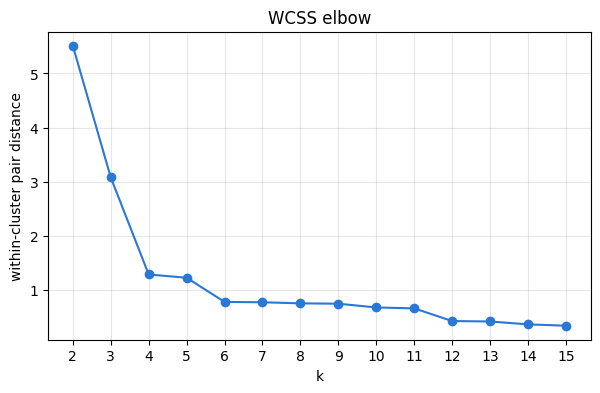

In [55]:
from sklearn.cluster import AgglomerativeClustering

def wcss(dist, labels):
    total = 0.0
    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        if len(idx) < 2:
            continue
        total += dist[np.ix_(idx, idx)].sum() / 2
    return total

inertias = []
for k in ks:
    lab = AgglomerativeClustering(
        n_clusters=int(k), metric="precomputed", linkage="complete"
    ).fit_predict(dist)
    inertias.append(wcss(dist, lab))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, inertias, marker="o", color="#2a78d6")
ax.set_xlabel("k")
ax.set_ylabel("within-cluster pair distance")
ax.set_title("WCSS elbow")
ax.set_xticks(ks)
ax.grid(True, alpha=0.3)
plt.show()

In [56]:
n_clusters = 6

## Observed feature cosine

In [60]:
import plotly.graph_objects as go
import networkx as nx
from sklearn.cluster import AgglomerativeClustering

def plot_cluster_graph(sim, cluster_labels, title, lo_intra=0.0, lo_inter=0.45):
    G = nx.Graph()
    for i, name in enumerate(assets):
        G.add_node(name, cluster=int(cluster_labels[i]))
    for i in range(len(assets)):
        for j in range(i + 1, len(assets)):
            w = float(sim[i, j])
            same = cluster_labels[i] == cluster_labels[j]
            if same and w >= lo_intra:
                G.add_edge(assets[i], assets[j], weight=w, intra=True)
            elif (not same) and w >= lo_inter:
                G.add_edge(assets[i], assets[j], weight=w, intra=False)
    intra = [(u, v) for u, v, d in G.edges(data=True) if d["intra"]]
    inter = [(u, v) for u, v, d in G.edges(data=True) if not d["intra"]]
    rng = np.random.default_rng(0)
    k = int(np.max(cluster_labels) + 1)
    angles = np.linspace(0, 2 * np.pi, k, endpoint=False)
    centers = {c: 2.2 * np.array([np.cos(a), np.sin(a)]) for c, a in enumerate(angles)}
    pos0 = {
        name: centers[data["cluster"]] + rng.normal(scale=0.18, size=2)
        for name, data in G.nodes(data=True)
    }
    G_layout = nx.Graph()
    G_layout.add_nodes_from(G.nodes)
    G_layout.add_edges_from(
        (u, v, {"weight": max(G[u][v]["weight"], 1e-3)}) for u, v in intra
    )
    pos = nx.spring_layout(G_layout, pos=pos0, seed=0, weight="weight", k=1.8, iterations=80)

    def edge_trace(pairs, color, width, name):
        x, y, hx, hy, hover = [], [], [], [], []
        for u, v in pairs:
            x += [pos[u][0], pos[v][0], None]
            y += [pos[u][1], pos[v][1], None]
            hx.append(0.5 * (pos[u][0] + pos[v][0]))
            hy.append(0.5 * (pos[u][1] + pos[v][1]))
            hover.append(f"{u} — {v}<br>cosine {G[u][v]['weight']:.3f}")
        line = go.Scatter(
            x=x, y=y, mode="lines", name=name, hoverinfo="skip",
            line=dict(color=color, width=width),
        )
        dots = go.Scatter(
            x=hx, y=hy, mode="markers", name=f"{name} cosine",
            marker=dict(size=6, color=color, opacity=0),
            hovertemplate="%{text}<extra></extra>",
            text=hover,
            showlegend=False,
        )
        return line, dots

    fig = go.Figure()
    intra_line, intra_hover = edge_trace(intra, "rgba(42,120,214,0.75)", 2.0, "same cluster")
    inter_line, inter_hover = edge_trace(inter, "rgba(214, 80, 42, 0.55)", 1.2, "cross-cluster")
    fig.add_trace(intra_line)
    fig.add_trace(inter_line)
    fig.add_trace(intra_hover)
    fig.add_trace(inter_hover)
    palette = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#393b79",
    ]
    for c in range(k):
        nodes = [n for n in G.nodes if G.nodes[n]["cluster"] == c]
        fig.add_trace(go.Scatter(
            x=[pos[n][0] for n in nodes],
            y=[pos[n][1] for n in nodes],
            mode="markers+text",
            name=f"cluster {c} ({len(nodes)})",
            text=nodes,
            textposition="top center",
            textfont=dict(size=8),
            marker=dict(size=12, color=palette[c % len(palette)]),
            hovertemplate="%{text}<br>cluster %{meta}<extra></extra>",
            meta=[c] * len(nodes),
        ))
    fig.update_layout(
        title=title, width=900, height=900, showlegend=True,
        xaxis=dict(visible=False),
        yaxis=dict(visible=False, scaleanchor="x"),
        plot_bgcolor="white",
    )
    fig.show()


train_days = np.asarray(dates <= TRAIN_END)
mean_cos = np.nanmean(cosine[:, :, train_days], axis=2)
cos_dist = np.clip(1.0 - mean_cos, 0, 2)
np.fill_diagonal(cos_dist, 0)
cos_labels = AgglomerativeClustering(
    n_clusters=n_clusters, metric="precomputed", linkage="complete"
).fit_predict(cos_dist)
print("observed cosine sizes")
print(pd.Series(cos_labels).value_counts().sort_index())
plot_cluster_graph(mean_cos, cos_labels, f"{n_clusters} observed cosine clusters")


observed cosine sizes
0    29
1     7
2    34
3    12
4     9
5     9
Name: count, dtype: int64


## TGCN embedding cosine

In [58]:
from sklearn.cluster import AgglomerativeClustering

model.eval()
H = []
hidden_state = None
with torch.no_grad():
    for snapshot in train_dataset:
        x = snapshot.x.to(device)
        edge_index_t = snapshot.edge_index.to(device)
        edge_attr = snapshot.edge_attr.to(device)
        _, hidden_state = model(x, edge_index_t, edge_attr, hidden_state)
        H.append(hidden_state.detach().cpu().numpy())

H = np.stack(H, axis=-1)
emb = H.mean(axis=2)
emb_n = emb / np.linalg.norm(emb, axis=1, keepdims=True).clip(min=1e-8)
pred_cos = emb_n @ emb_n.T
dist = np.clip(1.0 - pred_cos, 0, 2)
np.fill_diagonal(dist, 0)

emb_labels = AgglomerativeClustering(
    n_clusters=n_clusters, metric="precomputed", linkage="complete"
).fit_predict(dist)
print("TGCN embedding sizes")
print(pd.Series(emb_labels).value_counts().sort_index())

TGCN embedding sizes
0    17
1    28
2    35
3     6
4    13
5     1
Name: count, dtype: int64


In [59]:
plot_cluster_graph(pred_cos, emb_labels, f"{n_clusters} TGCN embedding clusters")
